# <font color="#a9000b"> Wine Clustering with Machine Learning Project : </font>

&nbsp;&nbsp;&nbsp;Bir şarabın yapımında sizce kaç farklı içerik gereklidir? Aslen bu sorunun cevabı için belirli sınıf sayısı illaki vardır ve istenildiği kadar katılan malzeme başlığı arttırılabilir. Fakat bu bir şaraptır demek için ideal malzeme başlık sayısı nedir, bunu tahmin edebilen bir modelleme yapacağız bu projede. Modelimiz şaraba katılacak başlık sayısının idealini bizim  için belirliyor olacaktır. Öncelikle şarap yapımında kullanılan bazı malzemelerin başlıklarını içeren excel dosyamızı okuyup daha sonrasında da ideal küme sayısını belirlemek adına sınıflandırma yapacağımızdan bu bir Clustering Projesi oluyor. <br>
&nbsp;&nbsp;&nbsp;Kümeleme yapmamız gerektiğinden elimizdeki datayı Elbow yani dirsek analizimize göre ideal grup sayısına bölmek olacaktır. Bu hedef baz alınarak silhouette_score üzerinden şarap malzeme sayısı için ideal grup sayısını belirliyor olacağız. Önce geleneksel Kmeans yöntemi üzerinden ilerleyip daha sonrasında datamızı Derin Öğrenme ile eğitip ideal grup sayısını tahmin edebilen bir model olacağız.

In [23]:
# Merhaba,
# Bu ödevde verilecek cevaplarıma kullanmak adına karar kıldığım Font '#a9000b' dur.

#### Veri Sözlüğüm : <br>
**Alcohol:** Alkol<br>
**Malic_Acid:** Malik Asit<br>
**Ash:** Kül<br>
**Ash_Alcanity:** Kül Alkanitesi<br>
**Magnesium:** Magnezyum<br>
**Total_Phenols:** Toplam Fenoller<br>
**Flavanoids:** Flavonoidler<br>
**Nonflavanoid_Phenols:** Flavonoid Olmayan Fenoller<br>
**Proanthocyanins:** Proantosiyaninler<br>
**Color_Intensity:** Renk Yoğunluğu<br>
**Hue:** Ton<br>
**OD280:** OD280<br>
**Proline:** Prolin<br>

***Hedef: Şarap yapımında En Az Kaç Küme başlığı altında malzeme kullanmamız gerektiğine Karar Vermek***<br>

<img src='https://saraplik.com/wp-content/uploads/2023/07/wine-culture.webp'>

In [81]:
import pandas as pd
pd.set_option('display.max_columns',100)

import numpy as np
import datetime as dt

import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
import sqlite3

from yellowbrick.cluster import KElbowVisualizer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from tensorflow.keras import layers, models
from matplotlib.colors import LinearSegmentedColormap

from joblib import dump
from sklearn.cluster import KMeans

import umap

&nbsp;&nbsp;&nbsp;Önce bir şarabın yapımında kullanılan oranları içeren csv dosyamızı çekelim.

In [3]:
df = pd.read_csv('wine-clustering.csv')

## <font color="#a9000b"> EDA - Exploratory Data Analysis: </font>

&nbsp;&nbsp;&nbsp;Datamız hakkında bilgi edinmek ile projemize başlıyoruz.

In [4]:
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [25]:
df.tail()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.3,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.2,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.3,0.60,1.62,840
177,14.13,4.10,2.74,24.5,96,2.05,0.76,0.56,1.35,9.2,0.61,1.60,560


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [26]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


&nbsp;&nbsp;&nbsp;Şimdi veri setimizde boş değer var mıdır bakalım.

In [7]:
df.isnull().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

In [32]:
df.corr()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
Alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
Malic_Acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
Ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
Ash_Alcanity,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
Magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
Total_Phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
Flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
Nonflavanoid_Phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
Proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417
Color_Intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100


&nbsp;&nbsp;&nbsp;Datamızın korelasyonunu görsel olarak incelemek için kod yazmaya devam edelim.

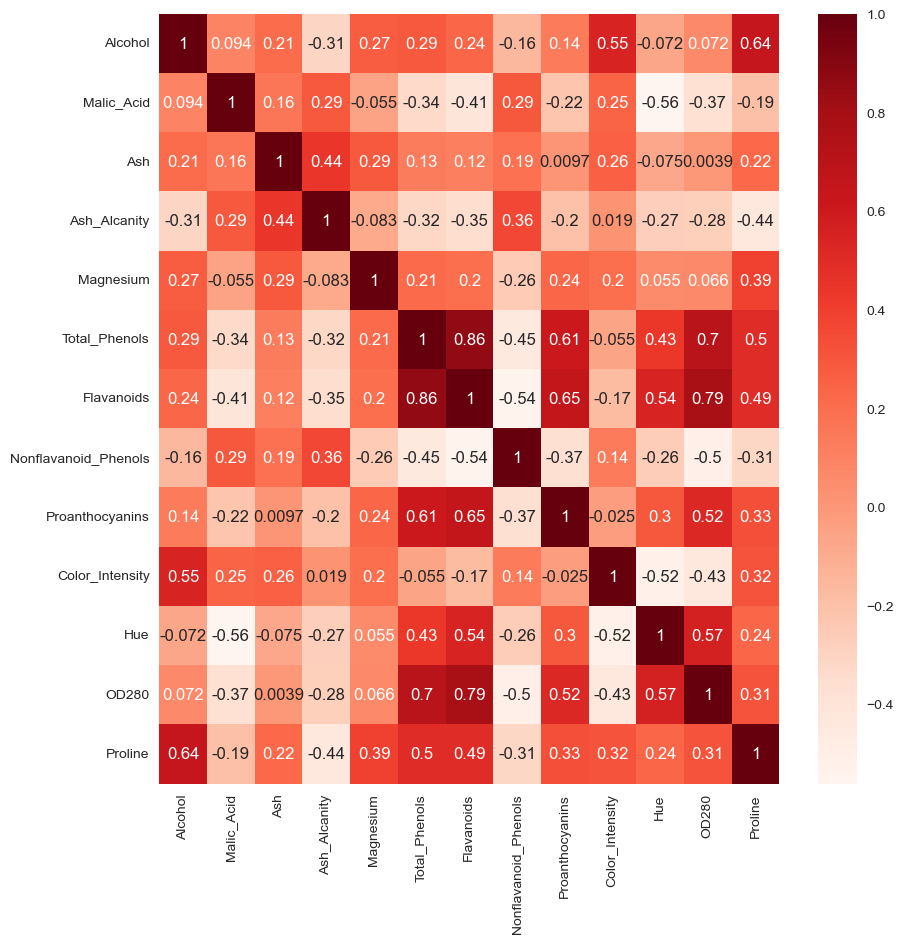

In [34]:
plt.figure(figsize=(10,10)) # her bir satira 7 inc vermis oluyoruz
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap="Reds");

&nbsp;&nbsp;&nbsp;Son olarak sütun ve satır sayımızı da görelim.

In [6]:
df.shape

(178, 13)

&nbsp;&nbsp;&nbsp; Şimdi veri setimizi inceledik. Gördüğümüz kadarıyla üzerinde işlem yapmamızı gerektirecek string ifadeler ya da boş değerler mevcut değil. Bu durumda diğer bölümde sütunların durumuna görsel olarak göz atalım.

## <font color="#a9000b"> Feature Engineering: </font>

&nbsp;&nbsp;&nbsp; Öncelikle 'Alcohol' sütununun dağılımını inceleyelim.

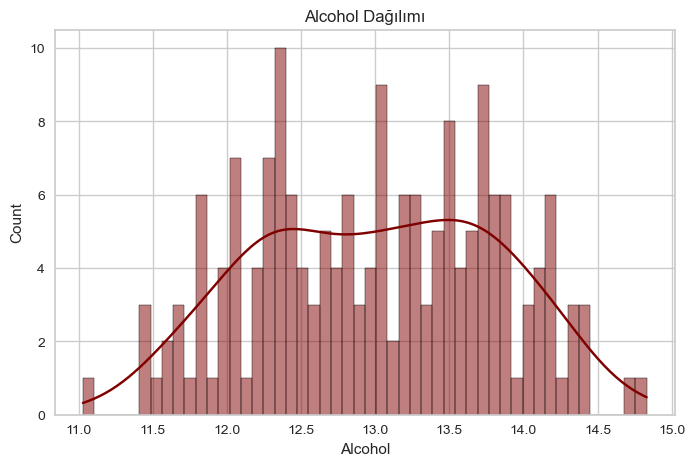

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df['Alcohol'], kde=True, bins=50, color="#800000")  # bordo hex
plt.xlabel('Alcohol')
plt.title('Alcohol Dağılımı')
plt.show()

&nbsp;&nbsp;&nbsp; Şimdi de 'Color_Intensity' sütununa yani renk yoğunluğunu sütununun dağılımına bakalım.

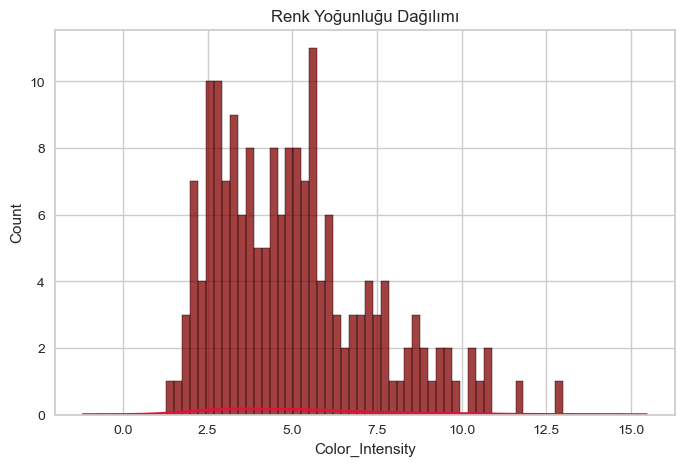

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['Color_Intensity'], kde=False, bins=50, color="#800000")
sns.kdeplot(df['Color_Intensity'], color="crimson", lw=2)  # KDE'yi ayrı çiz
plt.xlabel('Color_Intensity')
plt.title('Renk Yoğunluğu Dağılımı')
plt.show()

&nbsp;&nbsp;&nbsp; Artık şarap yapılacakken kullanılacak ideal kategori yani sınıf sayısını belirleyebilmek adına model oluşturma bölümüne geçebiliriz.

## <font color="#a9000b"> Model and Testing: </font>

&nbsp;&nbsp;&nbsp;Önce model oluşturuyoruz sonra test edeceğiz. İlk olarak ideal küme sayısı olarak rastgele 3 verdik fakat test ederek ideal küme sayısını bulduktan sonra bu değeri değiştireceğiz.

In [8]:
model=KMeans(3) 

In [9]:
model=model.fit(df)

In [10]:
tahmin=model.predict(df)

In [11]:
silhouette_score(df,tahmin)

np.float64(0.571138193786884)

&nbsp;&nbsp;&nbsp; Bu sonuç datamızın başlıklarının %57 gibi bir oranda birbirine benzediğini gösteriyor. Hadi bunu görselleştirelim.

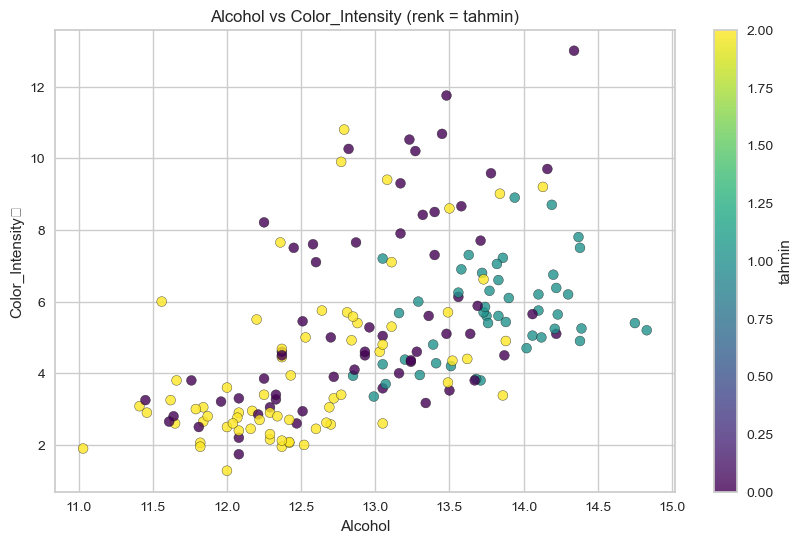

In [15]:
plt.figure(figsize=(10,6))
sc = plt.scatter(df['Alcohol'], df['Color_Intensity'], c=tahmin, cmap='viridis', s=50, alpha=0.8, edgecolor='k')
plt.colorbar(sc, label='tahmin')  
plt.xlabel('Alcohol')
plt.ylabel('Color_Intensity	')
plt.title('Alcohol vs Color_Intensity (renk = tahmin)')
plt.show()

&nbsp;&nbsp;&nbsp;Şimdi de inertia'ya yani datamızın sınıflandırmaya tabi iken tekrar ettiği noktaya bakalım.

In [16]:
#wcss= within cluster sum of squares
wcss=[]
ss=[]
for i in range(2,10):
    model=KMeans(i)
    model=model.fit(df)
    tahmin=model.predict(df)
    ss1=silhouette_score(df,tahmin)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.655521358978658
0.571138193786884
0.5587089480903827
0.5081797474674725
0.510993278676416
0.5621677013863702
0.5064653487917512
0.5111594100549148


&nbsp;&nbsp;&nbsp;Yukarıdaki kodlara göre datamızın tekrara düşen noktası ya 4. adım gibi görünüyor. Bu durumda ideal kümeleme sayısı 4 olabilir. Bunu görsel olarak da inceleyerek netleştirelim.

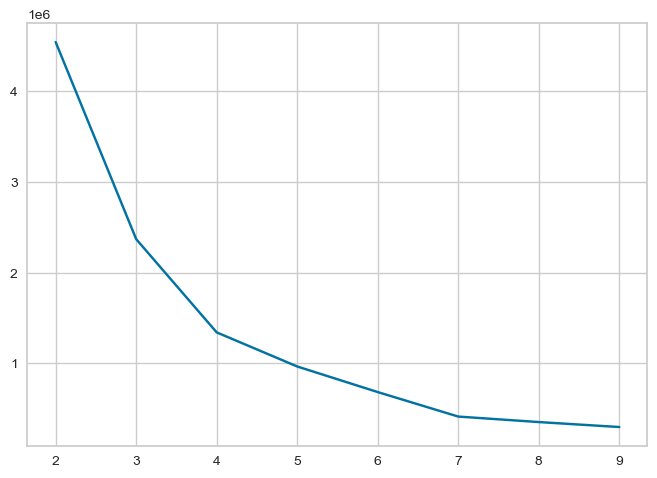

In [17]:
plt.plot(range(2,10),wcss);

&nbsp;&nbsp;&nbsp;Yukarıdaki grafikte görünen o ki 3 ideal grup sayısını vermiyor. Daha çok kırılma noktası 4 gibi görünüyor. Bu durumda daha detaylı çizime sahip olan başka bir grafikten yardım alalım.

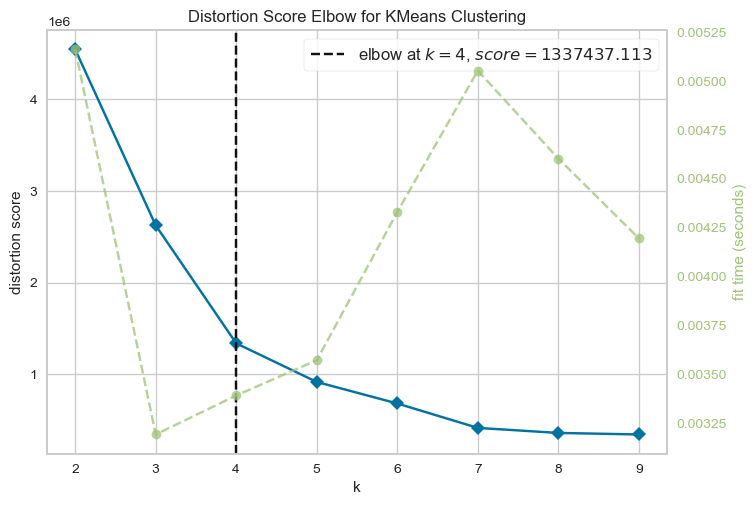

In [18]:
vis=KElbowVisualizer(KMeans(),k=(2,10))  # Elbow'a göre ideal grup sayısı 4 mus. Bu durumda datamızı 4 gruba ayıracagiz
vis.fit(df)
vis.show();

&nbsp;&nbsp;&nbsp;Madem kırılma noktası 4 olarak daha ideal çıkıyor, bu durumda modelimizi 4 kümeye ayırması adına tekrar modelleyelim.

In [59]:
model2=KMeans(4) 

In [60]:
model2=model2.fit(df)

In [61]:
tahmin2=model2.predict(df)

In [62]:
silhouette_score(df,tahmin2)

np.float64(0.5605941060060623)

In [64]:
dump(model2, "wine_clustering.joblib")

['wine_clustering.joblib']

&nbsp;&nbsp;&nbsp;Datamızı **Dendrogram** yani hiyerarşik kümeleme ile de görselleştirelim. Bu yöntem sonuçlarımızı ağaç biçiminde görselleştirmemize yardımcı olan bir diyagramdır.

In [65]:
data=linkage(df,method='ward',metric='euclidean')

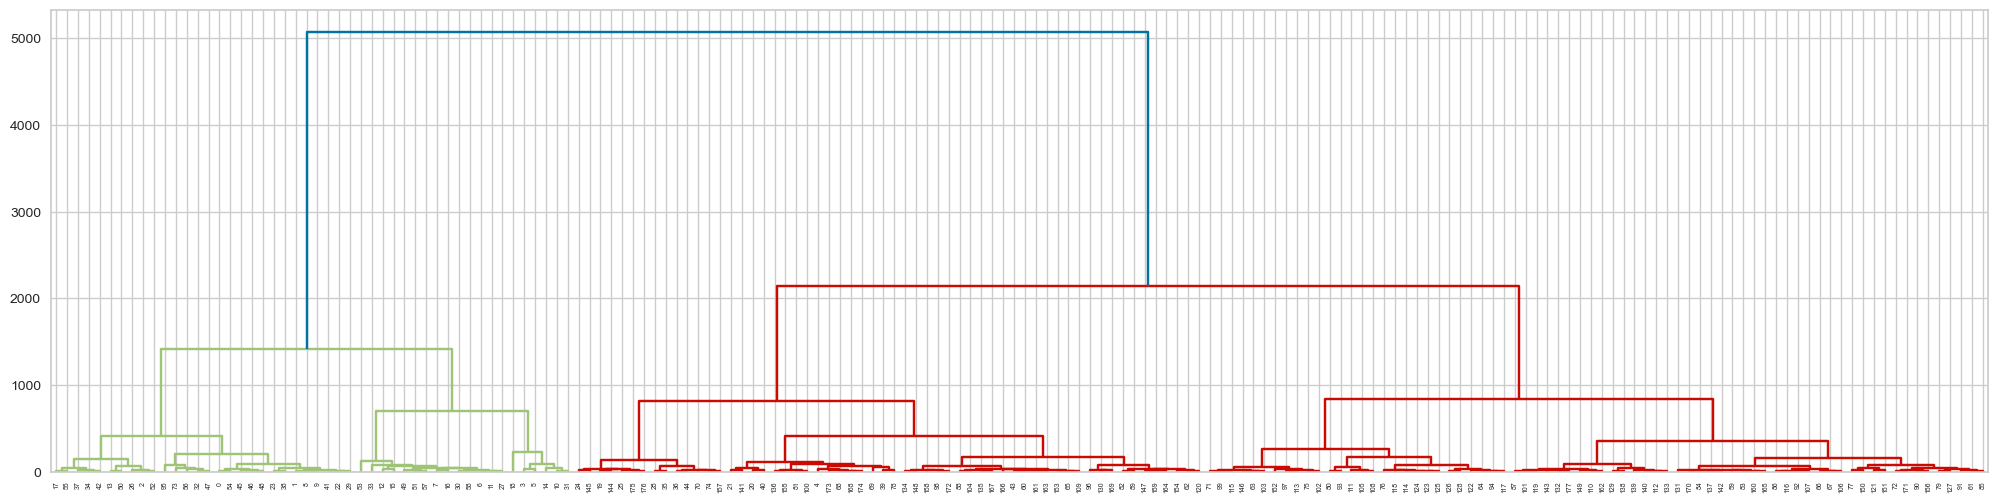

In [66]:
plt.figure(figsize=(25,6))
dendrogram(data);

&nbsp;&nbsp;&nbsp;Burada görüldüğü üzere görselimiz çok fazla sayısal değer olduğu için biraz yoğun oldu, bu sebeple bunu biraz sadeleştirecek bir hale indirgeyelim. 

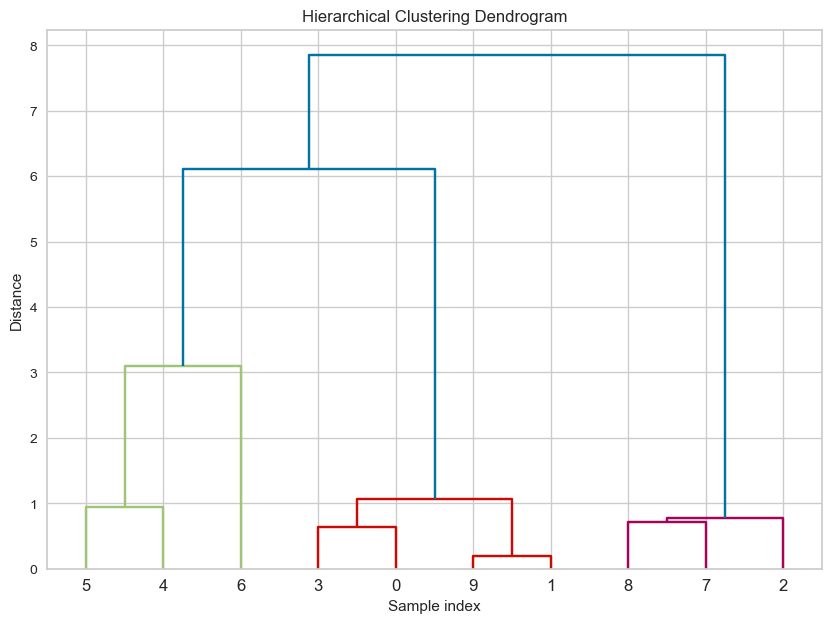

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage

# Generate sample data
X, _ = make_blobs(n_samples=10, centers=3, cluster_std=0.60, random_state=0)

# Perform hierarchical clustering
linked = linkage(X, 'ward')

# Create a dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

&nbsp;&nbsp;&nbsp;Bir de durumu DBSCAN diye adlandırılan yoğunluk tabanlı bir kümeleme algoritması olan kümeleme yönteminde görelim.

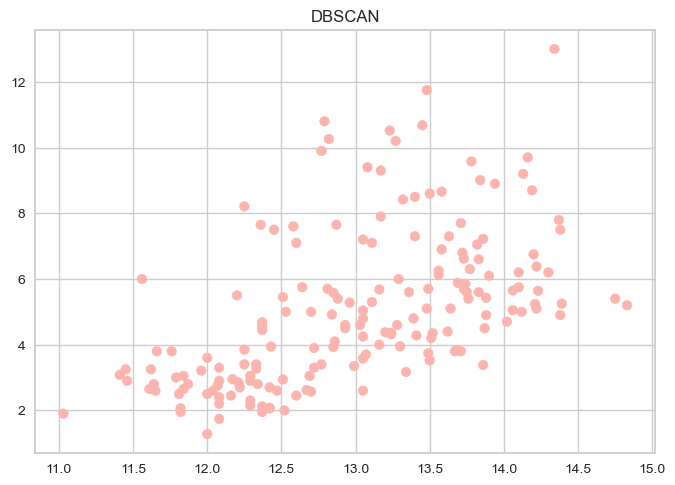

In [72]:
db=DBSCAN(min_samples=4)
from sklearn.preprocessing import StandardScaler
x2=StandardScaler().fit_transform(df)
y=db.fit_predict(x2)
plt.title("DBSCAN")
plt.scatter(df['Alcohol'],df['Color_Intensity'],c=y,cmap='Pastel1');

&nbsp;&nbsp;&nbsp;Son olarak da AgglomerativeClustering (agglomeratif hiyerarşik kümeleme), hiyerarşik kümeleme yöntemlerinin “bottom-up” (aşağıdan yukarı) yaklaşımı olan yöntem ile görelim. 

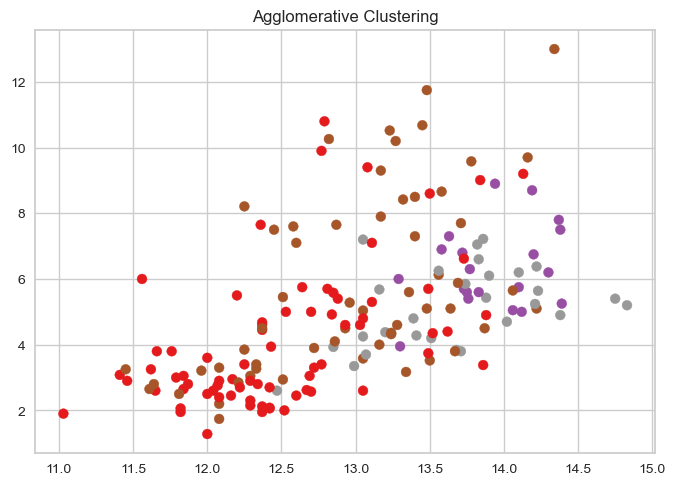

In [77]:
agg_clustering = AgglomerativeClustering(n_clusters=4)
y_agg = agg_clustering.fit_predict(df)

# Plot the results
plt.scatter(df['Alcohol'],df['Color_Intensity'], c=y_agg, s=50, cmap='Set1')
plt.title("Agglomerative Clustering")
plt.show()

&nbsp;&nbsp;&nbsp;Şimdi ise datamızı **Derin Öğrenme** ile eğitip sonuçları inceleyelim. Ama bundan önce datamızı Scale etmemiz gerekiyor.

In [78]:
df = StandardScaler().fit_transform(df)

In [79]:
# autoencoder
input_dim = df.shape[1]
encoding_dim = 10

input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = models.Model(inputs=input_layer, outputs=decoded)
encoder = models.Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(df, df, epochs=50, batch_size=32, validation_split=0.1)

# latent temsili al ve k-means uygula
Z = encoder.predict(df)
kmeans = KMeans(n_clusters=4, random_state=42).fit(Z)
labels = kmeans.labels_

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.9884 - val_loss: 1.1180
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9445 - val_loss: 1.0802
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9067 - val_loss: 1.0340
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8636 - val_loss: 0.9853
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8164 - val_loss: 0.9295
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7627 - val_loss: 0.8622
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7022 - val_loss: 0.7874
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6413 - val_loss: 0.7078
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5842 - val_loss: 0.6321
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5362 - val_loss: 0.5658
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4976 - val_loss: 0.5105
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4675 - val_loss: 0.4668
E

&nbsp;&nbsp;&nbsp;Ve sonucu görselleştirelim.

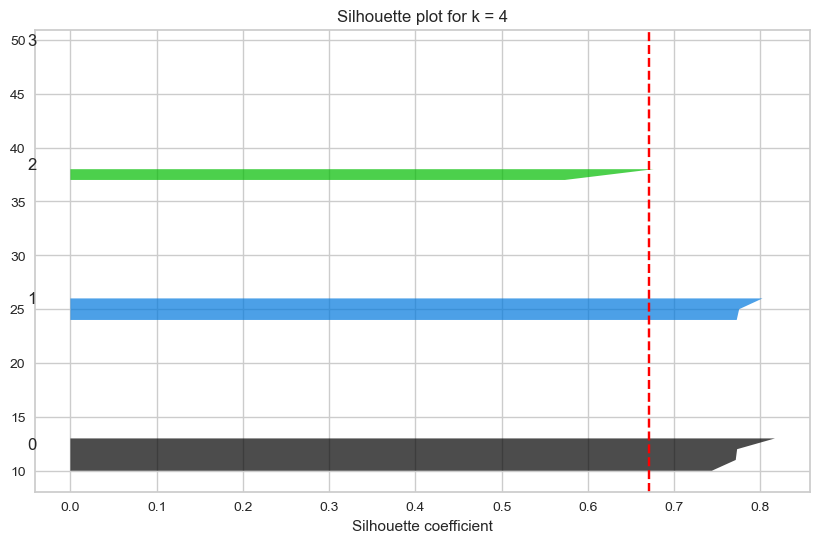

In [80]:
from sklearn.metrics import silhouette_samples
k = 4  # örnek: seçtiğin k
kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
labels = kmeans.labels_
sil_vals = silhouette_samples(X, labels)

plt.figure(figsize=(10,6))
y_lower = 10
for i in range(k):
    ith_sil_vals = sil_vals[labels == i]
    ith_sil_vals.sort()
    size_cluster_i = ith_sil_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    color = plt.cm.nipy_spectral(float(i) / k)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil_vals, facecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10  # boşluk

plt.axvline(x=sil_vals.mean(), color="red", linestyle="--")
plt.xlabel("Silhouette coefficient")
plt.title(f"Silhouette plot for k = {k}")
plt.show()

&nbsp;&nbsp;&nbsp;Derin öğrenme ile modeli eğitince de ideal sınıfa 4 küme verdik ve yukarıdaki gibi görselleştirdik. Ama daha net başka bir görsel ile destekleyelim sonucumuzu.

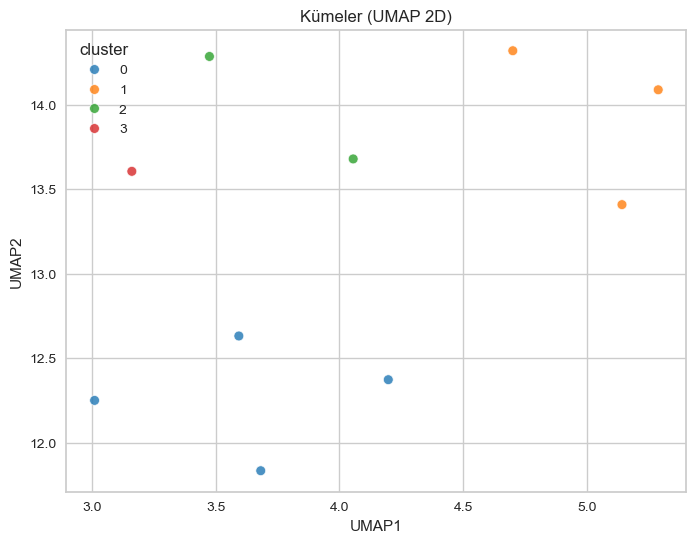

In [82]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=labels, palette='tab10', s=50, alpha=0.8)
plt.title('Kümeler (UMAP 2D)')
plt.xlabel('UMAP1'); plt.ylabel('UMAP2')
plt.legend(title='cluster')
plt.show()

**Conclusion:** &nbsp;&nbsp;Sonuç olarak; bu projede şarap yapılırken kullanılan çeşitli malzemelerini bildiğimiz durumda bir şarap için ideal malzeme sayısını içeren küme sayısını belirledik. Bizim datamız için ideal küme sayısı modelimizin tahmini üzerinden 4 geldi. Bu durumda bir şarap yapılacaksa bu başlıklardan minimum 4 farklı sınıfın içerik olarka kullanılması gerektiğini gösterir. Silhouette_score yani datamızın benzerlik oranı yaklaşık: 0.5711 çıktı. %57 gibi bir benzerlik oranı olsa bile en ideal küme sayısı 4 diyebiliyoruz. <br>
&nbsp;&nbsp;&nbsp;Yapılan bu model Clustering'i içerdiği için onun testleri ile gerçeklestirildi. Sonuçlar dendrogram haritaları üzerinde hiyerarşik olarak gösterildi. Ayrıyeten AgglomerativeClustering ile datanın kümelenme biçimine bakıldı. Son olarak da DBSCAN üzerinden datanın yoğunluğunun durumu hakkında da görsel oluşturuldu.<br>
&nbsp;&nbsp;&nbsp;Yine datamız Derin Öğrenme ile de eğitilip görselleştirdi.

Ve kapanış..